In [2]:
import salishsea_tools
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import netCDF4 as nc
from salishsea_tools import geo_tools

OUTPATH = '/ocean/ghoeven/MOAD/analysis-griffon/ResTimeOutput/'

In [22]:
# Only change these and then run the rest
regionName = 'BuddInlet30dTracers'
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/BuddInlet_30d_O2SalTracers/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

regionName = 'HoodCanal30dTracers'
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/HoodCanalTracers_30d/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

# regionName = 'HoodCanalBasin30dTracers'
# outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/HoodCanalBasinTracers_30d/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

regionName = 'LynchCove30dTracers'
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/LynchCoveTracers_30d/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

regionName = 'PennCove30dTracers'
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/PennCoveTracers_30d/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

# regionName = 'HolmesHarbour30dTracers'
# outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/HolmesHarbourTracers_30d/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

# regionName = 'AdmiraltyInlet30dTracers'
# outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/AdmiraltyInletTracers_30d/new_compw_forward_01jan18/ariane_positions_quantitative.nc'

dataf = xr.open_dataset(outputf)

/tmp/ipykernel_36568/2216799870.py:23: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dataf = xr.open_dataset(outputf)


In [23]:
dataf

<xarray.Dataset> Size: 7MB
Dimensions:        (ntraj: 41933)
Dimensions without coordinates: ntraj
Data variables: (12/25)
    init_x         (ntraj) float64 335kB ...
    init_y         (ntraj) float64 335kB ...
    init_z         (ntraj) float64 335kB ...
    init_t         (ntraj) float64 335kB ...
    init_age       (ntraj) timedelta64[ns] 335kB ...
    init_transp    (ntraj) float64 335kB ...
    ...             ...
    init_lon       (ntraj) float64 335kB ...
    init_lat       (ntraj) float64 335kB ...
    init_depth     (ntraj) float64 335kB ...
    final_lon      (ntraj) float64 335kB ...
    final_lat      (ntraj) float64 335kB ...
    final_depth    (ntraj) float64 335kB ...
Attributes: (12/108)
    key_roms:                  .FALSE.
    key_mars:                  .FALSE.
    key_symphonie:             .FALSE.
    key_B2C_grid:              .FALSE.
    key_sequential:            .TRUE.
    key_alltracers:            .TRUE.
    ...                        ...
    ind0_sa:                   1
    indn_sa:                   30
    maxsize_sa:                6
    c_suffix_sa:               _grid_T.nc
    nc_var_sa:                 vosaline
    nc_att_mask_sa:            NONE

Text(0, 0.5, '# Particles Leaving PennCove30dTracers')

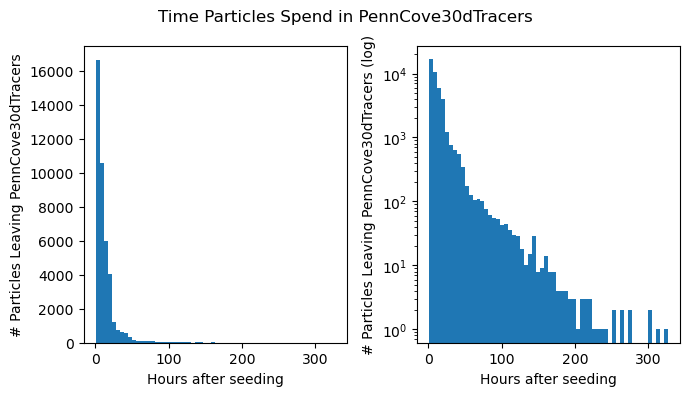

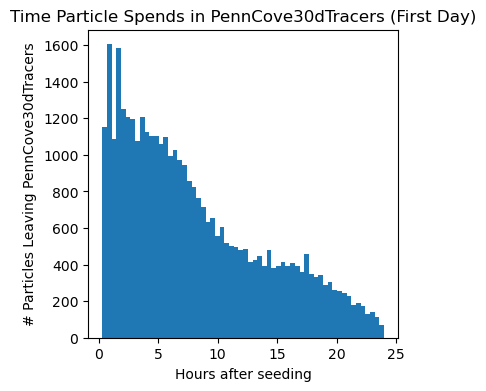

In [27]:
# Unfiltered histogram and stats
fin_age = dataf.final_age.values / np.timedelta64(1, 'h')

final_depth = dataf.final_depth.values

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4))
ax[0].hist(fin_age, bins=60, log=False, )
ax[0].set_xlabel('Hours after seeding')
ax[0].set_ylabel(f'# Particles Leaving {regionName}')

ax[1].hist(fin_age, bins=60, log=True, )
ax[1].set_xlabel('Hours after seeding')
ax[1].set_ylabel(f'# Particles Leaving {regionName} (log)')
fig.suptitle(f'Time Particles Spend in {regionName}')
plt.tight_layout()

fage_day1_filt = fin_age[~(fin_age > 24)]
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist(fage_day1_filt, bins=60, log=False, )
ax.set_title(f'Time Particle Spends in {regionName} (First Day)')
ax.set_xlabel('Hours after seeding')
ax.set_ylabel(f'# Particles Leaving {regionName}')


[257.04187 266.43973 283.87488 ... 226.21872 181.93253 178.02388]
[286.13788 297.96933 280.8975  ...   0.        0.        0.     ]
[ True  True  True ...  True  True  True]
<xarray.DataArray (ntraj: 41933)> Size: 42kB
array([False,  True, False, ...,  True,  True,  True], shape=(41933,))
Dimensions without coordinates: ntraj


Text(0, 0.5, '# Particles Leaving PennCove30dTracers')

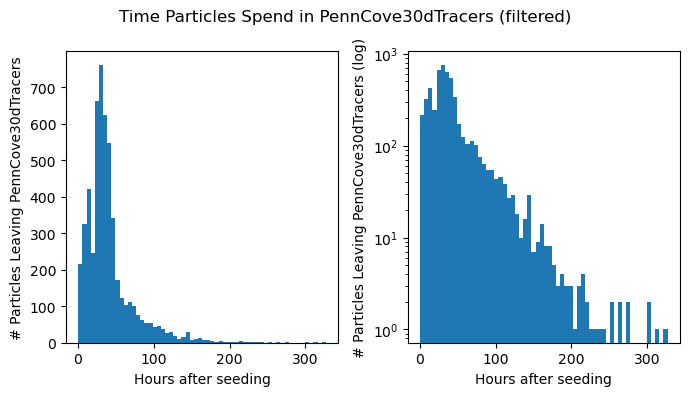

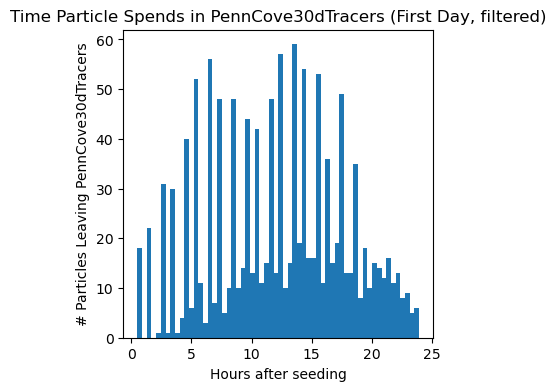

In [25]:
# Filtered histogram and stats with sal filter
fin_age = dataf.final_age.values / np.timedelta64(1, 'h')

init_salt = dataf.init_salt.values
init_ox = dataf.init_temp.values
final_salt = dataf.final_salt.values
final_ox = dataf.final_temp.values
init_depth = dataf.init_depth.values
final_depth = dataf.final_depth.values

print(init_ox)
print(final_ox)

sal_filter = ~((init_salt == final_salt))
print(sal_filter)
sal_filter = ~((init_salt >= final_salt-0.1) & (init_salt <= final_salt+0.1) & (init_ox >= final_ox-0.1) & (init_ox <= final_ox+0.1) )

sal_filter = ~((((init_salt >= final_salt-0.5) & (init_salt <= final_salt+0.5))
              | ((init_ox >= final_ox-0.5) & (init_ox <= final_ox+0.5))
              | ((dataf.init_depth <= (dataf.final_depth) + 2.5) & (dataf.init_depth >= (dataf.final_depth) - 2.5))
               ) & (fin_age < 24))


print(sal_filter)
sal_filter = xr.DataArray(sal_filter, dims=['ntraj'])
# print(type(tide_filter))
fage_filtered = fin_age[sal_filter]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4))
ax[0].hist(fage_filtered, bins=60, log=False, )
ax[0].set_xlabel('Hours after seeding')
ax[0].set_ylabel(f'# Particles Leaving {regionName}')

ax[1].hist(fage_filtered, bins=60, log=True, )
ax[1].set_xlabel('Hours after seeding')
ax[1].set_ylabel(f'# Particles Leaving {regionName} (log)')
fig.suptitle(f'Time Particles Spend in {regionName} (filtered)')
plt.tight_layout()

fage_day1_filt = fage_filtered[~(fage_filtered > 24)]
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist(fage_day1_filt, bins=60, log=False, )
ax.set_title(f'Time Particle Spends in {regionName} (First Day, filtered)')
ax.set_xlabel('Hours after seeding')
ax.set_ylabel(f'# Particles Leaving {regionName}')


In [21]:
print('Filtered Stats:')
print('Day 1 mean time (h) = ' + str(np.mean(fage_day1_filt)))
print('Total mean time in (h) = ' + str(np.mean(fage_filtered)))
print('Total mean time in (d) = ' + str(np.mean(fage_filtered)/24))

Filtered Stats:
Day 1 mean time (h) = 11.50348056998304
Total mean time in (h) = 90.10636797259765
Total mean time in (d) = 3.7544319988582355
